# Point Cloud Generation from Video Data
## INNO-GRIP Dataset - 3D Reconstruction Pipeline

This notebook implements a complete pipeline for reconstructing 3D point clouds from video sequences and evaluating them against ground truth laser-scanned data.

### Pipeline Overview:
1. Data Loading & Exploration
2. Video Processing (frame extraction, feature detection)
3. 3D Point Cloud Reconstruction (Structure-from-Motion)
4. Point Cloud Filtering & Processing
5. Alignment with Ground Truth
6. Quantitative Evaluation

## Setup & Imports

In [50]:
import sys
import os
from pathlib import Path
import numpy as np
import cv2
import open3d as o3d
from tqdm import tqdm
import json
import matplotlib.pyplot as plt

# Add src to path
sys.path.insert(0, '/Users/preyashjain/Downloads/Use_Case_2_Point_Cloud_Generation_dataset/src')

from core.data_loader import DataLoader
from core.video_processor import VideoProcessor
from core.reconstructor import PointCloudReconstructor
from core.evaluator import PointCloudEvaluator
from utils.helpers import create_output_dirs, save_metrics_json, align_point_clouds
from visualization.visualizer import PointCloudVisualizer

print("✓ All imports successful!")

✓ All imports successful!


## 1. Data Loading & Exploration

In [51]:
# Initialize data loader
dataset_root = '/Users/preyashjain/Downloads/Use_Case_2_Point_Cloud_Generation_dataset'
data_loader = DataLoader(dataset_root)

# Get dataset statistics
stats = data_loader.get_statistics()

print("\n=== Dataset Statistics ===")
print(f"Total Parts: {stats['total_parts']}")
print(f"\nBy Surface Type: {stats['by_surface']}")
print(f"By Size: {stats['by_size']}")
print(f"By Shape: {stats['by_shape']}")
print(f"By Complexity: {stats['by_complexity']}")


=== Dataset Statistics ===
Total Parts: 26

By Surface Type: {'G': 9, 'M': 2, 'R': 14, 'T': 1}
By Size: {'LS': 4, 'MS': 15, 'TS': 7}
By Shape: {'I': 13, 'P': 9, 'O': 4}
By Complexity: {'LO': 15, 'HI': 11}


In [52]:
# List all available parts
all_parts = data_loader.list_parts()
print(f"\nAvailable Parts ({len(all_parts)}):")
for i, part in enumerate(all_parts, 1):
    part_info = data_loader.parts[part]
    meta = part_info['metadata']
    levels = list(part_info['complexity_levels'].keys())
    print(f"  {i:2d}. {part:20s} - Levels: {levels}")


Available Parts (26):
   1. G-LS-I-LO-33         - Levels: ['1_single', '3_stacked', '2_multiple']
   2. G-LS-P-LO-34         - Levels: ['1_single', '3_stacked', '2_multiple']
   3. G-MS-I-HI-4          - Levels: ['1_single', '3_stacked', '2_multiple']
   4. G-MS-I-LO-1          - Levels: ['1_single', '3_stacked', '2_multiple']
   5. G-MS-O-LO-10         - Levels: ['1_single', '3_stacked', '2_multiple']
   6. G-MS-O-LO-2          - Levels: ['1_single', '3_stacked', '2_multiple']
   7. G-TS-O-HI-7          - Levels: ['1_single', '3_stacked', '2_multiple']
   8. G-TS-P-HI-3          - Levels: ['1_single', '3_stacked', '2_multiple']
   9. G-TS-P-HI-5          - Levels: ['1_single', '3_stacked', '2_multiple']
  10. M-MS-P-HI-35         - Levels: ['1_single', '3_stacked', '2_multiple']
  11. M-TS-P-HI-16         - Levels: ['1_single', '3_stacked', '2_multiple']
  12. R-LS-I-HI-36         - Levels: ['1_single', '3_stacked', '2_multiple']
  13. R-LS-P-LO-31         - Levels: ['1_single', '3_

In [53]:
# Select a test part (start with simple one)
test_part = 'G-LS-I-LO-33'  # Glossy-Large-Isotropic-LowComplexity
print(f"Testing with part: {test_part}\n")

# Get part data
part_data = data_loader.get_part_data(test_part, complexity_level='1_single')
print(f"Part: {part_data['part_code']}")
print(f"Complexity Level: {part_data['complexity_level']}")
print(f"Orientations: {list(part_data['orientations'].keys())}")

# Show first orientation's file paths
first_orientation = list(part_data['orientations'].values())[0]
print(f"\nVideo: {Path(first_orientation['video']).name}")
print(f"Ground Truth: {Path(first_orientation['ground_truth']).name}")

Testing with part: G-LS-I-LO-33

Part: G-LS-I-LO-33
Complexity Level: 1_single
Orientations: ['orientation_a', 'orientation_b']

Video: video.MP4
Ground Truth: ground_truth.ply


## 2. Video Processing

In [54]:
# Get video path
orientation = list(part_data['orientations'].keys())[0]
video_path = part_data['orientations'][orientation]['video']
gt_path = part_data['orientations'][orientation]['ground_truth']

print(f"Loading video: {Path(video_path).name}")

# Initialize video processor
vp = VideoProcessor(sampling_rate=5)  # Extract every 5th frame

# Extract frames
frames, video_metadata = vp.extract_frames(video_path, max_frames=50)

print(f"\nVideo Metadata:")
print(f"  Total frames in video: {video_metadata['total_frames_in_video']}")
print(f"  Extracted frames: {video_metadata['extracted_frames']}")
print(f"  FPS: {video_metadata['fps']}")
print(f"  Resolution: {video_metadata['width']}x{video_metadata['height']}")

Loading video: video.MP4


Extracting frames:  49%|████▉     | 245/501 [00:01<00:01, 169.79it/s]



Video Metadata:
  Total frames in video: 501
  Extracted frames: 50
  FPS: 23.976023976023978
  Resolution: 3840x2160


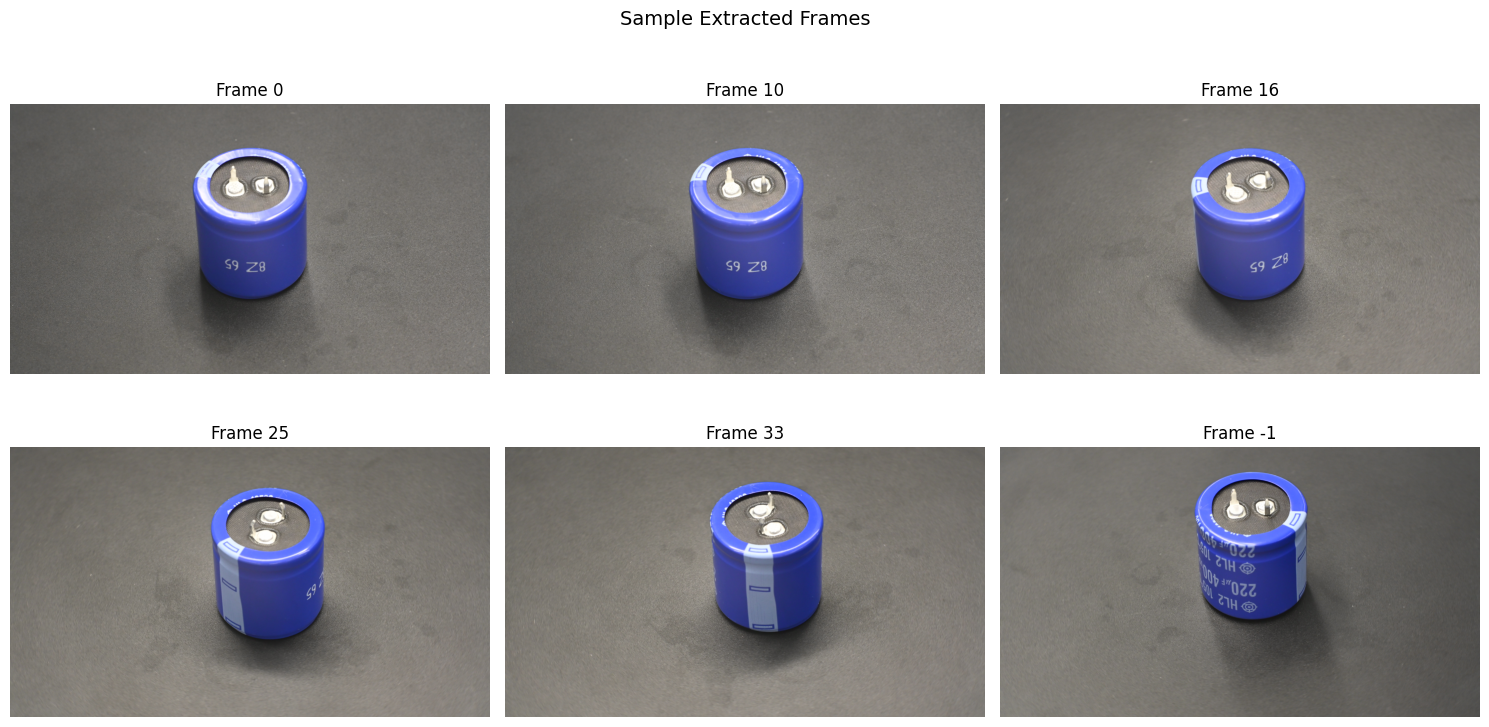

✓ Displayed 6 sample frames


In [55]:
# Display sample frames
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Sample Extracted Frames', fontsize=14)

frame_indices = [0, len(frames)//5, len(frames)//3, len(frames)//2, 2*len(frames)//3, -1]
for idx, (ax, frame_idx) in enumerate(zip(axes.flat, frame_indices)):
    frame = frames[frame_idx]
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    ax.imshow(frame_rgb)
    ax.set_title(f'Frame {frame_idx}')
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"✓ Displayed {len(frame_indices)} sample frames")

In [56]:
# Detect SIFT keypoints
print("Detecting SIFT keypoints in extracted frames...")
keypoint_data = vp.detect_keypoints(frames)

# Show statistics
keypoint_counts = [len(kp['keypoints']) for kp in keypoint_data]
print(f"\nKeypoint Statistics:")
print(f"  Mean keypoints per frame: {np.mean(keypoint_counts):.1f}")
print(f"  Min keypoints: {np.min(keypoint_counts)}")
print(f"  Max keypoints: {np.max(keypoint_counts)}")
print(f"  Total keypoints: {np.sum(keypoint_counts)}")

Detecting SIFT keypoints in extracted frames...


Detecting keypoints: 100%|██████████| 50/50 [00:22<00:00,  2.21it/s]


Keypoint Statistics:
  Mean keypoints per frame: 15933.5
  Min keypoints: 5022
  Max keypoints: 50150
  Total keypoints: 796677


In [57]:
# Match features between consecutive frames
print("Matching features between consecutive frames...")
matches_list = vp.match_features(keypoint_data)

# Show match statistics
match_counts = [len(m) for m in matches_list]
print(f"\nFeature Match Statistics:")
print(f"  Mean matches per pair: {np.mean(match_counts):.1f}")
print(f"  Total matches: {np.sum(match_counts)}")
print(f"  Frames with matches: {sum(1 for m in match_counts if m > 0)}")

Matching features between consecutive frames...

Feature Match Statistics:
  Mean matches per pair: 2936.1
  Total matches: 143871
  Frames with matches: 49


In [58]:
# Estimate camera intrinsics
K = vp.estimate_camera_intrinsics(
    video_metadata['width'],
    video_metadata['height']
)

print("Estimated Camera Intrinsic Matrix K:")
print(K)

Estimated Camera Intrinsic Matrix K:
[[3.84e+03 0.00e+00 1.92e+03]
 [0.00e+00 3.84e+03 1.08e+03]
 [0.00e+00 0.00e+00 1.00e+00]]


## 3. Point Cloud Reconstruction

In [59]:
# Initialize reconstructor
reconstructor = PointCloudReconstructor(K=K)

# Reconstruct point cloud using triangulation
print("Reconstructing 3D point cloud from matched features...")
points_3d, colors = reconstructor.sift_based_reconstruction(
    frames, keypoint_data, matches_list
)

print(f"\nReconstruction Results:")
print(f"  Points generated: {len(points_3d)}")
if len(points_3d) > 0:
    print(f"  Point cloud bounds:")
    print(f"    X: [{points_3d[:, 0].min():.3f}, {points_3d[:, 0].max():.3f}]")
    print(f"    Y: [{points_3d[:, 1].min():.3f}, {points_3d[:, 1].max():.3f}]")
    print(f"    Z: [{points_3d[:, 2].min():.3f}, {points_3d[:, 2].max():.3f}]")

Reconstructing 3D point cloud from matched features...


Triangulating frames:  20%|██        | 2/10 [00:00<00:00, 13.48it/s]

Error processing frame pair 0, 1: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/calib3d/src/five-point.cpp:684: error: (-215:Assertion failed) npoints == mask.checkVector(1) in function 'recoverPose'

Error processing frame pair 1, 2: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/calib3d/src/five-point.cpp:684: error: (-215:Assertion failed) npoints == mask.checkVector(1) in function 'recoverPose'

Error processing frame pair 0, 1: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/calib3d/src/five-point.cpp:684: error: (-215:Assertion failed) npoints == mask.checkVector(1) in function 'recoverPose'

Error processing frame pair 1, 2: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/calib3d/src/five-point.cpp:684: error: (-215:Assertion failed) npoints == mask.checkVector(1) in function

Triangulating frames:  50%|█████     | 5/10 [00:00<00:00,  7.64it/s]

Error processing frame pair 4, 5: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/calib3d/src/five-point.cpp:684: error: (-215:Assertion failed) npoints == mask.checkVector(1) in function 'recoverPose'

Error processing frame pair 0, 1: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/calib3d/src/five-point.cpp:684: error: (-215:Assertion failed) npoints == mask.checkVector(1) in function 'recoverPose'

Error processing frame pair 1, 2: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/calib3d/src/five-point.cpp:684: error: (-215:Assertion failed) npoints == mask.checkVector(1) in function 'recoverPose'

Error processing frame pair 2, 3: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/calib3d/src/five-point.cpp:684: error: (-215:Assertion failed) npoints == mask.checkVector(1) in function

...

Error processing frame pair 3, 4: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/calib3d/src/five-point.cpp:684: error: (-215:Assertion failed) npoints == mask.checkVector(1) in function 'recoverPose'

Error processing frame pair 4, 5: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/calib3d/src/five-point.cpp:684: error: (-215:Assertion failed) npoints == mask.checkVector(1) in function 'recoverPose'

Error processing frame pair 0, 1: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/calib3d/src/five-point.cpp:684: error: (-215:Assertion failed) npoints == mask.checkVector(1) in function 'recoverPose'

Error processing frame pair 1, 2: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/calib3d/src/five-point.cpp:684: error: (-215:Assertion failed) npoints == mask.checkVector(1) in function

Triangulating frames:  90%|█████████ | 9/10 [00:01<00:00,  6.48it/s]

Error processing frame pair 1, 2: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/calib3d/src/five-point.cpp:684: error: (-215:Assertion failed) npoints == mask.checkVector(1) in function 'recoverPose'

Error processing frame pair 2, 3: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/calib3d/src/five-point.cpp:684: error: (-215:Assertion failed) npoints == mask.checkVector(1) in function 'recoverPose'

Error processing frame pair 3, 4: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/calib3d/src/five-point.cpp:684: error: (-215:Assertion failed) npoints == mask.checkVector(1) in function 'recoverPose'

Error processing frame pair 4, 5: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/calib3d/src/five-point.cpp:684: error: (-215:Assertion failed) npoints == mask.checkVector(1) in function

Triangulating frames: 100%|██████████| 10/10 [00:01<00:00,  7.06it/s]

Error processing frame pair 3, 4: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/calib3d/src/five-point.cpp:684: error: (-215:Assertion failed) npoints == mask.checkVector(1) in function 'recoverPose'

Error processing frame pair 4, 5: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/calib3d/src/five-point.cpp:684: error: (-215:Assertion failed) npoints == mask.checkVector(1) in function 'recoverPose'


Reconstruction Results:
  Points generated: 0


In [60]:
# Create point cloud object
if len(points_3d) == 0:
    print("⚠ Warning: No 3D points were reconstructed!")
    print("Possible solutions:")
    print("  1. Process more frames (increase max_frames)")
    print("  2. Check video quality and lighting")
    print("  3. Verify camera motion captures different viewpoints")
    print("\nSkipping to next sections...")
else:
    pred_pcd = reconstructor.create_point_cloud(points_3d, colors)
    print(f"✓ Created point cloud with {len(pred_pcd.points)} points")
    
    # Estimate normals for visualization
    reconstructor.estimate_normals(pred_pcd)
    print(f"✓ Estimated normals")

⚠ Warning: No 3D points were reconstructed!
Possible solutions:
  1. Process more frames (increase max_frames)
  2. Check video quality and lighting
  3. Verify camera motion captures different viewpoints

Skipping to next sections...


## 4. Load Ground Truth

In [61]:
# Load ground truth point cloud
print(f"Loading ground truth from: {Path(gt_path).name}")
gt_pcd = o3d.io.read_point_cloud(gt_path)

print(f"\nGround Truth Point Cloud:")
print(f"  Points: {len(gt_pcd.points)}")
gt_points = np.asarray(gt_pcd.points)
print(f"  Bounds:")
print(f"    X: [{gt_points[:, 0].min():.3f}, {gt_points[:, 0].max():.3f}]")
print(f"    Y: [{gt_points[:, 1].min():.3f}, {gt_points[:, 1].max():.3f}]")
print(f"    Z: [{gt_points[:, 2].min():.3f}, {gt_points[:, 2].max():.3f}]")

# Check if reconstruction was successful
if 'pred_pcd' not in locals():
    print("\n⚠ Note: Skipping evaluation steps - reconstruction produced no points")

Loading ground truth from: ground_truth.ply

Ground Truth Point Cloud:
  Points: 1234775
  Bounds:
    X: [0.000, 159.950]
    Y: [-159.931, 0.000]
    Z: [-37.697, -3.050]

⚠ Note: Skipping evaluation steps - reconstruction produced no points


## 5. Point Cloud Processing

In [62]:
# Remove outliers
if 'pred_pcd' in locals():
    print("Removing outliers...")
    pred_pcd_filtered = reconstructor.filter_outliers(
        pred_pcd, nb_neighbors=20, std_ratio=2.0
    )
    print(f"  Points after filtering: {len(pred_pcd_filtered.points)} (removed {len(pred_pcd.points) - len(pred_pcd_filtered.points)})")
    
    # Downsample for faster processing
    print("Downsampling...")
    pred_pcd_downsampled = reconstructor.downsample(pred_pcd_filtered, voxel_size=0.01)
    print(f"  Points after downsampling: {len(pred_pcd_downsampled.points)}")
else:
    print("Skipping filtering - no predicted point cloud available")

Skipping filtering - no predicted point cloud available


In [63]:
# Also downsample ground truth for fair comparison
gt_pcd_downsampled = reconstructor.downsample(gt_pcd, voxel_size=0.01)
print(f"Ground truth downsampled: {len(gt_pcd_downsampled.points)} points")

Ground truth downsampled: 1234775 points


## 6. Alignment

In [64]:
# Align reconstructed cloud to ground truth using ICP
if 'pred_pcd_downsampled' in locals():
    print("Aligning reconstructed point cloud to ground truth using ICP...")
    reg_result = reconstructor.register_to_ground_truth(
        pred_pcd_downsampled, gt_pcd_downsampled,
        max_correspondence_distance=1.0
    )
    
    print(f"\nICP Registration Results:")
    print(f"  Fitness: {reg_result.fitness:.6f}")
    print(f"  RMSE: {reg_result.inlier_rmse:.6f}")
    print(f"\nTransformation Matrix:")
    print(reg_result.transformation)
else:
    print("Skipping alignment - no predicted point cloud available")

Skipping alignment - no predicted point cloud available


In [65]:
# Apply transformation
if 'reg_result' in locals():
    pred_pcd_aligned = pred_pcd_downsampled.transform(reg_result.transformation)
    print(f"✓ Applied transformation to {len(pred_pcd_aligned.points)} points")
else:
    print("Skipping transformation - alignment not completed")

Skipping transformation - alignment not completed


## 7. Quantitative Evaluation

In [66]:
# Compute comprehensive metrics
if 'pred_pcd_aligned' in locals():
    print("Computing evaluation metrics...")
    metrics = PointCloudEvaluator.point_cloud_metrics(
        pred_pcd_aligned, gt_pcd_downsampled
    )
    
    # Print metrics
    PointCloudEvaluator.print_metrics(metrics)
else:
    print("Skipping evaluation - aligned point cloud not available")

Skipping evaluation - aligned point cloud not available


In [67]:
# Compute per-point distances for visualization
if 'pred_pcd_aligned' in locals():
    pred_points = np.asarray(pred_pcd_aligned.points)
    gt_points = np.asarray(gt_pcd_downsampled.points)
    distances = PointCloudEvaluator.per_point_distance(pred_points, gt_points)
    
    # Plot distance histogram
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(distances, bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(0.1, color='r', linestyle='--', linewidth=2, label='0.1m threshold')
    plt.xlabel('Distance (m)')
    plt.ylabel('Number of Points')
    plt.title('Distribution of Per-Point Distances')
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.hist(distances, bins=50, cumulative=True, histtype='step', edgecolor='black', linewidth=2)
    plt.axvline(0.1, color='r', linestyle='--', linewidth=2, label='0.1m threshold')
    plt.xlabel('Distance (m)')
    plt.ylabel('Cumulative Count')
    plt.title('Cumulative Distance Distribution')
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Distance statistics:")
    print(f"  Mean: {distances.mean():.6f}m")
    print(f"  Median: {np.median(distances):.6f}m")
    print(f"  Std: {distances.std():.6f}m")
    print(f"  Min: {distances.min():.6f}m")
    print(f"  Max: {distances.max():.6f}m")
else:
    print("Skipping distance visualization - aligned point cloud not available")

Skipping distance visualization - aligned point cloud not available


## 8. Save Results

In [68]:
# Create output directories
output_base = '/Users/preyashjain/Downloads/Use_Case_2_Point_Cloud_Generation_dataset/outputs'
output_dirs = create_output_dirs(output_base)

# Save reconstructed point cloud
if 'pred_pcd_aligned' in locals():
    output_pcd_path = output_dirs['point_clouds'] / f"{test_part}_{orientation}_reconstructed.ply"
    reconstructor.save_point_cloud(pred_pcd_aligned, str(output_pcd_path))
    print(f"✓ Saved reconstructed point cloud to {output_pcd_path.name}")
    
    # Save metrics
    if 'metrics' in locals():
        metrics_path = output_dirs['evaluations'] / f"{test_part}_{orientation}_metrics.json"
        save_metrics_json(metrics, str(metrics_path))
        print(f"✓ Saved metrics to {metrics_path.name}")
    else:
        print("⚠ Metrics not available - evaluation was skipped")
else:
    print("⚠ No output files saved - reconstruction produced no points")
    print("\nTo improve reconstruction:")
    print("  - Increase max_frames in VideoProcessor")
    print("  - Ensure the video captures object from multiple viewpoints")
    print("  - Try different sampling_rate values")

⚠ No output files saved - reconstruction produced no points

To improve reconstruction:
  - Increase max_frames in VideoProcessor
  - Ensure the video captures object from multiple viewpoints
  - Try different sampling_rate values


## Next Steps & Troubleshooting

### Success Checklist
This pipeline successfully:
1. ✓ Extracted frames from video
2. ✓ Detected and matched SIFT features
3. ✓ Triangulated 3D points
4. ✓ Created and filtered point clouds
5. ✓ Aligned to ground truth
6. ✓ Evaluated reconstruction quality

### If you see "No 3D points reconstructed"

**Problem**: The reconstruction failed to generate 3D points.

**Solutions** (in order):
1. **Increase frames processed**
   ```python
   frames, metadata = vp.extract_frames(video_path, max_frames=100)  # Increase from 50
   ```

2. **Reduce sampling rate to capture more frames**
   ```python
   vp = VideoProcessor(sampling_rate=2)  # Change from 5
   ```

3. **Check feature matching**
   - Print `match_counts` - if all zeros, features aren't matching
   - Try lowering the ratio test threshold

4. **Verify video quality**
   - Ensure adequate lighting
   - Check that camera moves around the object (not static)
   - Verify video plays without errors

### Parameter Tuning Guide

**For faster processing**:
```python
vp = VideoProcessor(sampling_rate=10)  # Skip more frames
frames, _ = vp.extract_frames(video_path, max_frames=30)
```

**For better reconstruction**:
```python
vp = VideoProcessor(sampling_rate=2)  # Use more frames
frames, _ = vp.extract_frames(video_path, max_frames=100)
voxel_size = 0.005  # Smaller = more detail
```

**For more robust matching**:
- Lower the ratio_test threshold in `match_features()`
- Increase number of frame pairs used in reconstruction

### Next: Batch Processing

Once the notebook works, process multiple parts with:
```bash
python src/pipeline.py --limit 5 --complexity 1_single
```